# STAT3612 Group Project - DNN Baseline (Multimodal Tabular + Text + Deep Features)

## Task Summary
- Build a **5-class presurgical brain tumor classifier** using only provided data.
- Data sources used in this notebook:
  - Clinical information
  - Radiomics features (4 MRI modalities)
  - Raw radiology report text (findings)
  - Pre-extracted deep image features (`image.npy`, 2048-d per modality)
- Train a **Deep Neural Network (MLP)** and evaluate with **weighted/macro F1**.
- Add interpretation via **group ablation** and **group permutation importance**.
- Generate Kaggle submission file with format:
  - `case_id,Overall_class`

## Important Constraint
No external data is used in this notebook.

In [ ]:
import os
import json
import random
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Make training behavior as deterministic as possible for reproducibility.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ROOT = Path("kaggle-dataset")
IMAGE_ROOT = ROOT / "image_features" / "image_features"
MODALITIES = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]

Device: cuda


In [2]:
def load_json_dict(filename):
    with open(ROOT / filename, "r") as f:
        return json.load(f)


def load_split_tables(split):
    clinical = pd.read_csv(ROOT / "clinical_information" / f"{split}_patient_info.csv")
    raw_report = pd.read_csv(ROOT / "original_raw_report" / f"{split}_patient_info.csv")

    clinical["case_id"] = clinical["case_id"].astype(str)
    raw_report["case_id"] = raw_report["case_id"].astype(str)

    merged = clinical.merge(raw_report, on="case_id", how="left")

    # Radiomics (4 modality tables -> wide format)
    rad_frames = []
    for mod in MODALITIES:
        rad = pd.read_csv(ROOT / "radiomics_info" / split / f"{mod}_radiomics_{split}.csv")
        rad["case_id"] = rad["case_id"].astype(str)

        drop_cols = [c for c in ["sex", "age", "modality"] if c in rad.columns]
        rad = rad.drop(columns=drop_cols)

        rename_map = {c: f"{mod}__{c}" for c in rad.columns if c != "case_id"}
        rad = rad.rename(columns=rename_map)
        rad_frames.append(rad)

    rad_wide = rad_frames[0]
    for i in range(1, len(rad_frames)):
        rad_wide = rad_wide.merge(rad_frames[i], on="case_id", how="outer")

    merged = merged.merge(rad_wide, on="case_id", how="left")

    return merged


def load_labels_from_json(filename):
    data = load_json_dict(filename)
    rows = []
    for case_id, info in data.items():
        rows.append({"case_id": str(case_id), "Overall_class": info.get("Overall_class")})
    return pd.DataFrame(rows)


def extract_image_features(case_ids):
    # Per modality: 2048-d embedding + 1 presence flag, concatenated across 4 modalities.
    out = []
    for cid in case_ids:
        case_block = []
        case_dir = IMAGE_ROOT / str(cid)
        for mod in MODALITIES:
            p = case_dir / mod / "image.npy"
            if p.exists():
                arr = np.load(p).astype(np.float32).reshape(-1)
                if arr.shape[0] != 2048:
                    arr = np.resize(arr, 2048).astype(np.float32)
                flag = np.array([1.0], dtype=np.float32)
            else:
                arr = np.zeros(2048, dtype=np.float32)
                flag = np.array([0.0], dtype=np.float32)
            case_block.append(np.concatenate([arr, flag]))
        out.append(np.concatenate(case_block))
    return np.vstack(out).astype(np.float32)


train_df = load_split_tables("train").merge(load_labels_from_json("train.json"), on="case_id", how="left")
val_df = load_split_tables("val").merge(load_labels_from_json("val.json"), on="case_id", how="left")
test_df = load_split_tables("test")

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)
print("Train class distribution:")
print(train_df["Overall_class"].value_counts())

Shapes: (1983, 30) (283, 30) (572, 29)
Train class distribution:
Overall_class
Glioma                                     924
Meningioma                                 728
Brain Metastase Tumour                     252
Tumors of the sellar region                 56
Pineal tumour and Choroid plexus tumour     23
Name: count, dtype: int64


In [3]:
def prepare_tabular_and_text(train_df, val_df, test_df):
    feature_cols = [c for c in train_df.columns if c not in ["case_id", "Overall_class", "raw_report"]]

    # Identify categorical and numeric columns from train split.
    categorical_cols = [c for c in feature_cols if train_df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    # Build tabular features by one-hot encoding categoricals and median-imputing numerics.
    if numeric_cols:
        X_train_num = train_df[numeric_cols].copy().apply(pd.to_numeric, errors="coerce")
        X_val_num = val_df[numeric_cols].copy().apply(pd.to_numeric, errors="coerce")
        X_test_num = test_df[numeric_cols].copy().apply(pd.to_numeric, errors="coerce")

        medians = X_train_num.median(numeric_only=True)
        X_train_num = X_train_num.fillna(medians)
        X_val_num = X_val_num.fillna(medians)
        X_test_num = X_test_num.fillna(medians)

        scaler_tab = StandardScaler()
        X_train_num_s = scaler_tab.fit_transform(X_train_num).astype(np.float32)
        X_val_num_s = scaler_tab.transform(X_val_num).astype(np.float32)
        X_test_num_s = scaler_tab.transform(X_test_num).astype(np.float32)
    else:
        X_train_num_s = np.zeros((len(train_df), 0), dtype=np.float32)
        X_val_num_s = np.zeros((len(val_df), 0), dtype=np.float32)
        X_test_num_s = np.zeros((len(test_df), 0), dtype=np.float32)

    if categorical_cols:
        X_train_cat = pd.get_dummies(train_df[categorical_cols].fillna("missing").astype(str), drop_first=False)
        X_val_cat = pd.get_dummies(val_df[categorical_cols].fillna("missing").astype(str), drop_first=False)
        X_test_cat = pd.get_dummies(test_df[categorical_cols].fillna("missing").astype(str), drop_first=False)

        X_val_cat = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0)
        X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

        X_train_cat_v = X_train_cat.values.astype(np.float32)
        X_val_cat_v = X_val_cat.values.astype(np.float32)
        X_test_cat_v = X_test_cat.values.astype(np.float32)
    else:
        X_train_cat_v = np.zeros((len(train_df), 0), dtype=np.float32)
        X_val_cat_v = np.zeros((len(val_df), 0), dtype=np.float32)
        X_test_cat_v = np.zeros((len(test_df), 0), dtype=np.float32)

    X_train_tab = np.hstack([X_train_num_s, X_train_cat_v])
    X_val_tab = np.hstack([X_val_num_s, X_val_cat_v])
    X_test_tab = np.hstack([X_test_num_s, X_test_cat_v])

    # Text features from raw report findings
    tfidf = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=600,
        min_df=2
    )

    train_text = train_df["raw_report"].fillna("").astype(str).values
    val_text = val_df["raw_report"].fillna("").astype(str).values
    test_text = test_df["raw_report"].fillna("").astype(str).values

    X_train_text = tfidf.fit_transform(train_text).toarray().astype(np.float32)
    X_val_text = tfidf.transform(val_text).toarray().astype(np.float32)
    X_test_text = tfidf.transform(test_text).toarray().astype(np.float32)

    return X_train_tab, X_val_tab, X_test_tab, X_train_text, X_val_text, X_test_text, tfidf


X_train_tab, X_val_tab, X_test_tab, X_train_text, X_val_text, X_test_text, tfidf_model = prepare_tabular_and_text(train_df, val_df, test_df)

X_train_img = extract_image_features(train_df["case_id"].tolist())
X_val_img = extract_image_features(val_df["case_id"].tolist())
X_test_img = extract_image_features(test_df["case_id"].tolist())

scaler_img = StandardScaler()
X_train_img = scaler_img.fit_transform(X_train_img).astype(np.float32)
X_val_img = scaler_img.transform(X_val_img).astype(np.float32)
X_test_img = scaler_img.transform(X_test_img).astype(np.float32)

# Defensive cleanup for occasional NaN/Inf from upstream feature sources.
def ensure_finite(x):
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

X_train_tab = ensure_finite(X_train_tab)
X_val_tab = ensure_finite(X_val_tab)
X_test_tab = ensure_finite(X_test_tab)
X_train_text = ensure_finite(X_train_text)
X_val_text = ensure_finite(X_val_text)
X_test_text = ensure_finite(X_test_text)
X_train_img = ensure_finite(X_train_img)
X_val_img = ensure_finite(X_val_img)
X_test_img = ensure_finite(X_test_img)

# Concatenate all modality groups for DNN input
X_train = np.hstack([X_train_tab, X_train_text, X_train_img]).astype(np.float32)
X_val = np.hstack([X_val_tab, X_val_text, X_val_img]).astype(np.float32)
X_test = np.hstack([X_test_tab, X_test_text, X_test_img]).astype(np.float32)

X_train = ensure_finite(X_train)
X_val = ensure_finite(X_val)
X_test = ensure_finite(X_test)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["Overall_class"])
y_val = label_encoder.transform(val_df["Overall_class"])

print("Feature shape (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", list(label_encoder.classes_))
print("Non-finite count (train/val/test):", np.sum(~np.isfinite(X_train)), np.sum(~np.isfinite(X_val)), np.sum(~np.isfinite(X_test)))

# Track group indices for ablation / permutation analysis
group_slices = {}
start = 0
group_slices["tabular"] = (start, start + X_train_tab.shape[1])
start += X_train_tab.shape[1]
group_slices["text"] = (start, start + X_train_text.shape[1])
start += X_train_text.shape[1]
group_slices["image_deep"] = (start, start + X_train_img.shape[1])
print("Group slices:", group_slices)

Feature shape (train/val/test): (1983, 8823) (283, 8823) (572, 8823)
Classes: ['Brain Metastase Tumour', 'Glioma', 'Meningioma', 'Pineal tumour and Choroid plexus tumour', 'Tumors of the sellar region']
Group slices: {'tabular': (0, 27), 'text': (27, 627), 'image_deep': (627, 8823)}


In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(1024, 512, 256), dropout=0.35):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_loader(X, y=None, batch_size=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(Xt)
    else:
        yt = torch.tensor(y, dtype=torch.long)
        ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate_model(model, loader):
    model.eval()
    probs_all, preds_all, y_all = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            probs_all.append(probs)
            preds_all.append(preds)
            y_all.append(yb.numpy())

    y_true = np.concatenate(y_all)
    y_pred = np.concatenate(preds_all)
    y_prob = np.concatenate(probs_all)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    class_weights,
    lr=1e-3,
    max_epochs=60,
    patience=10,
    monitor_metric="f1_weighted",
):
    if monitor_metric not in {"f1_weighted", "f1_macro"}:
        raise ValueError("monitor_metric must be 'f1_weighted' or 'f1_macro'")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "val_f1_weighted": [], "val_f1_macro": []}

    best_state = None
    best_score = -1.0
    best_epoch = -1
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            if not torch.isfinite(logits).all():
                raise ValueError("Non-finite logits detected. Please verify feature preprocessing.")

            loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                raise ValueError("Non-finite loss detected. Try lowering learning rate or rechecking features.")

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_metrics = evaluate_model(model, val_loader)
        current_score = val_metrics[monitor_metric]

        history["train_loss"].append(train_loss)
        history["val_f1_weighted"].append(val_metrics["f1_weighted"])
        history["val_f1_macro"].append(val_metrics["f1_macro"])

        improved = current_score > best_score
        if improved:
            best_score = current_score
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train_loss={train_loss:.4f} "
                f"| val_f1_weighted={val_metrics['f1_weighted']:.4f} "
                f"| val_f1_macro={val_metrics['f1_macro']:.4f} "
                f"| monitor={monitor_metric}:{current_score:.4f}"
            )

        if no_improve >= patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best epoch={best_epoch}, best {monitor_metric}={best_score:.4f}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch, best_score

Epoch 001 | train_loss=nan | val_f1_weighted=0.0287 | val_f1_macro=0.0451
Epoch 005 | train_loss=nan | val_f1_weighted=0.0287 | val_f1_macro=0.0451
Epoch 010 | train_loss=nan | val_f1_weighted=0.0287 | val_f1_macro=0.0451
Early stopping at epoch 11. Best epoch=1, best val weighted F1=0.0287
Best epoch: 1, Best val weighted F1: 0.0287
Validation weighted F1: 0.0287
Validation macro F1: 0.0451

Classification report (validation):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.1272    1.0000    0.2257        36
                                 Glioma     0.0000    0.0000    0.0000       132
                             Meningioma     0.0000    0.0000    0.0000       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.0000    0.0000    0.0000         8

                               accuracy                         0.1272       283

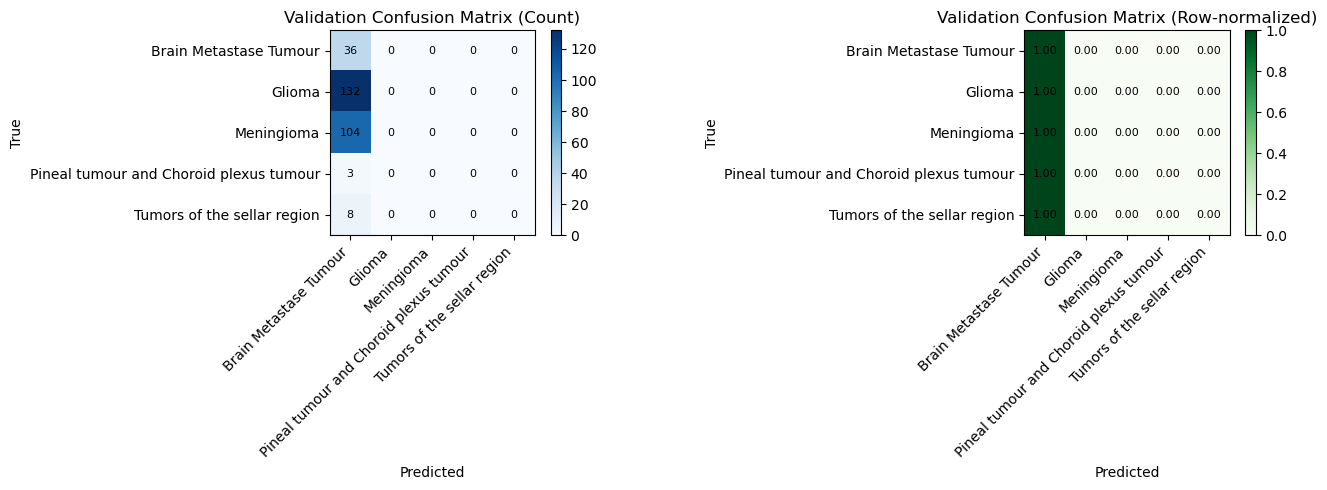

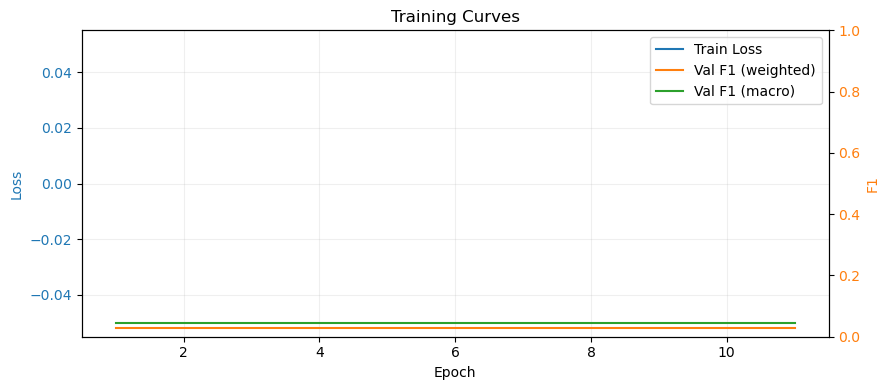

In [ ]:
# Priority-2/3: configurable monitor metric and cleaner reporting.
MONITOR_METRIC = "f1_macro"  # choose from: "f1_weighted", "f1_macro"

train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=256, shuffle=False)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights_t = torch.tensor(weights, dtype=torch.float32, device=device)

model = MLPClassifier(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_)).to(device)
model, history, best_epoch, best_score = train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    class_weights=class_weights_t,
    lr=3e-4,
    max_epochs=80,
    patience=15,
    monitor_metric=MONITOR_METRIC,
)

print(f"Best epoch: {best_epoch}, Best {MONITOR_METRIC}: {best_score:.4f}")

val_metrics = evaluate_model(model, val_loader)
print("Validation weighted F1:", round(val_metrics["f1_weighted"], 4))
print("Validation macro F1:", round(val_metrics["f1_macro"], 4))

print("\nClassification report (validation):")
print(
    classification_report(
        val_metrics["y_true"],
        val_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4
    )
)

# Quick sanity check: detect prediction collapse to a single class.
pred_counts = pd.Series(val_metrics["y_pred"]).value_counts().sort_index()
print("\nPredicted class distribution on validation:")
for idx, name in enumerate(label_encoder.classes_):
    print(f"{name}: {int(pred_counts.get(idx, 0))}")

cm = confusion_matrix(val_metrics["y_true"], val_metrics["y_pred"])
cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, cm_row_sum, where=cm_row_sum != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Validation Confusion Matrix (Count)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks(np.arange(len(label_encoder.classes_)))
axes[0].set_yticks(np.arange(len(label_encoder.classes_)))
axes[0].set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
axes[0].set_yticklabels(label_encoder.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cm_norm, cmap="Greens", vmin=0.0, vmax=1.0)
axes[1].set_title("Validation Confusion Matrix (Row-normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticks(np.arange(len(label_encoder.classes_)))
axes[1].set_yticks(np.arange(len(label_encoder.classes_)))
axes[1].set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
axes[1].set_yticklabels(label_encoder.classes_)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Use dual y-axis so loss and F1 are both readable.
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(epochs, history["train_loss"], color="tab:blue", label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.2)

ax2.plot(epochs, history["val_f1_weighted"], color="tab:orange", label="Val F1 (weighted)")
ax2.plot(epochs, history["val_f1_macro"], color="tab:green", label="Val F1 (macro)")
ax2.set_ylabel("F1", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0.0, 1.0)

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")
ax1.set_title("Training Curves")
plt.tight_layout()
plt.show()

In [ ]:
# Priority-4 optimization: K-fold stability export (CSV + JSON) with runtime mode switch.
RUN_MODE = "fast"  # choose from: "fast", "standard"
ENABLE_KFOLD_EXPORT = True

if RUN_MODE == "fast":
    KFOLD_SPLITS = 2
    KFOLD_MAX_EPOCHS = 20
    KFOLD_PATIENCE = 5
elif RUN_MODE == "standard":
    KFOLD_SPLITS = 3
    KFOLD_MAX_EPOCHS = 40
    KFOLD_PATIENCE = 8
else:
    raise ValueError("RUN_MODE must be 'fast' or 'standard'")

print(f"K-fold mode: {RUN_MODE} | splits={KFOLD_SPLITS}, max_epochs={KFOLD_MAX_EPOCHS}, patience={KFOLD_PATIENCE}")

if ENABLE_KFOLD_EXPORT:
    kf = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=SEED)
    fold_rows = []

    for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_train, y_train), start=1):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        tr_loader = make_loader(X_tr, y_tr, batch_size=64, shuffle=True)
        va_loader = make_loader(X_va, y_va, batch_size=256, shuffle=False)

        cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr), y=y_tr)
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)

        fold_model = MLPClassifier(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_)).to(device)
        fold_model, _, fold_best_epoch, fold_best_score = train_with_early_stopping(
            fold_model,
            tr_loader,
            va_loader,
            class_weights=cw_t,
            lr=3e-4,
            max_epochs=KFOLD_MAX_EPOCHS,
            patience=KFOLD_PATIENCE,
            monitor_metric=MONITOR_METRIC,
        )

        fold_metrics = evaluate_model(fold_model, va_loader)
        fold_rows.append({
            "fold": fold_id,
            "best_epoch": int(fold_best_epoch),
            f"best_{MONITOR_METRIC}": float(fold_best_score),
            "val_f1_weighted": float(fold_metrics["f1_weighted"]),
            "val_f1_macro": float(fold_metrics["f1_macro"]),
        })

    kfold_df = pd.DataFrame(fold_rows)
    display(kfold_df)

    weighted_mean = float(kfold_df["val_f1_weighted"].mean())
    weighted_std = float(kfold_df["val_f1_weighted"].std(ddof=1)) if len(kfold_df) > 1 else 0.0
    macro_mean = float(kfold_df["val_f1_macro"].mean())
    macro_std = float(kfold_df["val_f1_macro"].std(ddof=1)) if len(kfold_df) > 1 else 0.0

    print("\nK-fold Mean ± std")
    print("weighted F1:", f"{weighted_mean:.4f} ± {weighted_std:.4f}")
    print("macro F1:", f"{macro_mean:.4f} ± {macro_std:.4f}")

    outputs_dir = ROOT / "outputs"
    outputs_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    csv_path = outputs_dir / f"kfold_metrics_{ts}.csv"
    json_path = outputs_dir / f"kfold_summary_{ts}.json"

    kfold_df.to_csv(csv_path, index=False)

    summary_payload = {
        "timestamp": ts,
        "run_mode": RUN_MODE,
        "monitor_metric": MONITOR_METRIC,
        "kfold_splits": KFOLD_SPLITS,
        "kfold_max_epochs": KFOLD_MAX_EPOCHS,
        "kfold_patience": KFOLD_PATIENCE,
        "num_features": int(X_train.shape[1]),
        "num_classes": int(len(label_encoder.classes_)),
        "class_names": [str(x) for x in label_encoder.classes_],
        "mean_val_f1_weighted": weighted_mean,
        "std_val_f1_weighted": weighted_std,
        "mean_val_f1_macro": macro_mean,
        "std_val_f1_macro": macro_std,
        "per_fold": fold_rows,
    }

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(summary_payload, f, ensure_ascii=False, indent=2)

    print("\nSaved k-fold metrics:", csv_path)
    print("Saved k-fold summary:", json_path)
else:
    print("K-fold export is disabled.")

In [ ]:
# Priority-5 optimization: auto-generate report-ready text from latest k-fold exports.
outputs_dir = ROOT / "outputs"

if not outputs_dir.exists():
    print("No outputs directory found. Please run the k-fold export cell first.")
else:
    summary_files = sorted(outputs_dir.glob("kfold_summary_*.json"))
    metrics_files = sorted(outputs_dir.glob("kfold_metrics_*.csv"))

    if not summary_files or not metrics_files:
        print("No k-fold export files found. Please run the k-fold export cell first.")
    else:
        latest_summary = summary_files[-1]
        latest_metrics = metrics_files[-1]

        with open(latest_summary, "r", encoding="utf-8") as f:
            ksum = json.load(f)

        kdf = pd.read_csv(latest_metrics)

        top_fold_row = kdf.sort_values("val_f1_macro", ascending=False).iloc[0]
        top_fold = int(top_fold_row["fold"])
        top_macro = float(top_fold_row["val_f1_macro"])
        top_weighted = float(top_fold_row["val_f1_weighted"])

        report_lines = [
            "## K-fold Stability Summary (Auto-generated)",
            "",
            f"- Timestamp: {ksum.get('timestamp', 'N/A')}",
            f"- Run mode: {ksum.get('run_mode', 'N/A')}",
            f"- Monitor metric: {ksum.get('monitor_metric', 'N/A')}",
            f"- Splits: {ksum.get('kfold_splits', 'N/A')}",
            f"- Mean weighted F1: {ksum.get('mean_val_f1_weighted', 0.0):.4f}",
            f"- Std weighted F1: {ksum.get('std_val_f1_weighted', 0.0):.4f}",
            f"- Mean macro F1: {ksum.get('mean_val_f1_macro', 0.0):.4f}",
            f"- Std macro F1: {ksum.get('std_val_f1_macro', 0.0):.4f}",
            "",
            "### Interpretation for Report",
            (
                "The k-fold results show the stability of the current DNN setting across different "
                "stratified train/validation splits. A lower standard deviation indicates better robustness."
            ),
            (
                f"In this run, the best fold is Fold {top_fold} with macro F1={top_macro:.4f} "
                f"and weighted F1={top_weighted:.4f}."
            ),
            (
                "For imbalanced classes, macro F1 is the main fairness indicator, while weighted F1 "
                "reflects prevalence-weighted overall performance."
            ),
        ]

        report_text = "\n".join(report_lines)
        print(report_text)

        snippet_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        report_md_path = outputs_dir / f"kfold_report_snippet_{snippet_ts}.md"
        report_txt_path = outputs_dir / f"kfold_report_snippet_{snippet_ts}.txt"

        with open(report_md_path, "w", encoding="utf-8") as f:
            f.write(report_text)

        with open(report_txt_path, "w", encoding="utf-8") as f:
            f.write(report_text)

        print("\nSaved report snippets:")
        print(report_md_path)
        print(report_txt_path)

        print("\nLatest files used:")
        print(latest_summary)
        print(latest_metrics)

In [ ]:
def predict_from_array(model, X, batch_size=256):
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)


def ablation_score(model, X_val, y_val, group_slices, average="weighted"):
    base_preds = predict_from_array(model, X_val)
    base = f1_score(y_val, base_preds, average=average)

    rows = []
    for g, (l, r) in group_slices.items():
        X_mod = X_val.copy()
        X_mod[:, l:r] = 0.0
        p = predict_from_array(model, X_mod)
        score = f1_score(y_val, p, average=average)
        rows.append({"group": g, "f1": score, "drop_from_base": base - score})

    out = pd.DataFrame(rows).sort_values("drop_from_base", ascending=False)
    return base, out


def permutation_group_importance(model, X_val, y_val, group_slices, n_repeats=3, average="weighted"):
    rng = np.random.default_rng(SEED)
    base_preds = predict_from_array(model, X_val)
    base = f1_score(y_val, base_preds, average=average)

    records = []
    for g, (l, r) in group_slices.items():
        drops = []
        for _ in range(n_repeats):
            X_perm = X_val.copy()
            perm_idx = rng.permutation(X_perm.shape[0])
            X_perm[:, l:r] = X_perm[perm_idx, l:r]
            p = predict_from_array(model, X_perm)
            s = f1_score(y_val, p, average=average)
            drops.append(base - s)
        records.append({
            "group": g,
            "mean_drop": float(np.mean(drops)),
            "std_drop": float(np.std(drops))
        })

    out = pd.DataFrame(records).sort_values("mean_drop", ascending=False)
    return base, out


INTERPRET_METRIC = "macro" if MONITOR_METRIC == "f1_macro" else "weighted"

base_f1, ablation_df = ablation_score(model, X_val, y_val, group_slices, average=INTERPRET_METRIC)
print(f"Base validation {INTERPRET_METRIC} F1:", round(base_f1, 4))
print("\nAblation result (higher drop = more important):")
display(ablation_df)

perm_base, perm_df = permutation_group_importance(
    model,
    X_val,
    y_val,
    group_slices,
    n_repeats=3,
    average=INTERPRET_METRIC,
)
print(f"\nPermutation group importance ({INTERPRET_METRIC} F1 drop):")
display(perm_df)

Base validation weighted F1: 0.0287

Ablation result (higher drop = more important):


,group,f1,drop_from_base
0,tabular,0.028712,0.0
1,text,0.028712,0.0
2,image_deep,0.028712,0.0



Permutation group importance (weighted F1 drop):


,group,mean_drop,std_drop
0,tabular,0.0,0.0
1,text,0.0,0.0
2,image_deep,0.0,0.0


In [11]:
test_preds_idx = predict_from_array(model, X_test)
test_preds_label = label_encoder.inverse_transform(test_preds_idx)

pred_df = pd.DataFrame({
    "case_id": test_df["case_id"].astype(int),
    "Overall_class": test_preds_label
})

sample_sub = pd.read_csv(ROOT / "sample_submission.csv")
sample_sub["case_id"] = sample_sub["case_id"].astype(int)

# Force exact submission order and verify case coverage.
submission = sample_sub[["case_id"]].merge(pred_df, on="case_id", how="left")
missing_pred = int(submission["Overall_class"].isna().sum())
if missing_pred > 0:
    raise ValueError(f"Missing predictions for {missing_pred} case_id(s). Check case_id alignment.")

submission = submission[["case_id", "Overall_class"]]

out_path = ROOT / "sample_submission_dnn.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows:", len(submission), "| Unique case_id:", submission["case_id"].nunique())
print(submission.head(10))
print("\nClass distribution in prediction:")
print(submission["Overall_class"].value_counts(dropna=False))

Saved: kaggle-dataset\sample_submission_dnn.csv
   case_id           Overall_class
0        1  Brain Metastase Tumour
1        5  Brain Metastase Tumour
2        9  Brain Metastase Tumour
3       14  Brain Metastase Tumour
4       35  Brain Metastase Tumour
5       48  Brain Metastase Tumour
6       50  Brain Metastase Tumour
7       52  Brain Metastase Tumour
8       55  Brain Metastase Tumour
9       58  Brain Metastase Tumour

Class distribution in prediction:
Overall_class
Brain Metastase Tumour    572
Name: count, dtype: int64


## Model Analysis and Storytelling (For Report)

### Modeling Choice
The final model is a feature-fusion MLP, not a raw-image CNN pipeline. This is aligned with the assignment setting: the dataset already provides pre-extracted deep image embeddings, radiomics, and structured/non-structured clinical context. We combine three groups of inputs: (1) tabular clinical + radiomics features, (2) TF-IDF vectors from raw radiology reports, and (3) pre-extracted deep embeddings (2048-d per modality), together with modality-presence flags.

This design is practical for two reasons. First, it avoids overfitting risk from end-to-end image training under limited sample size. Second, it enables transparent multimodal contribution analysis at feature-group level. The MLP then learns nonlinear interactions between heterogeneous sources (for example, report wording + radiomic texture + embedding patterns), which a single-modality baseline would miss.

### Imbalance and Metrics
The class distribution is notably imbalanced, so we use class-weighted cross-entropy during training to increase minority-class influence. Early stopping is applied to validation weighted F1 to prevent overfitting and stabilize optimization.

Evaluation reports weighted F1, macro F1, and confusion matrix together. Weighted F1 reflects practical overall performance under class prevalence; macro F1 evaluates class fairness by treating each class equally. Reading both is important: a high weighted F1 with weak macro F1 usually indicates underperformance on rare classes.

### How to Read Interpretability Results
Two global methods are used:
- Feature-group ablation: set one entire group (tabular, text, or deep image features) to zero and re-evaluate. A larger F1 drop means stronger reliance on that group.
- Group permutation importance: shuffle one feature group across validation samples and measure F1 degradation. If performance drops sharply, that group contains strong predictive signal.

If ablation and permutation rank groups similarly, conclusions are more robust. If rankings differ, it often indicates redundancy or cross-group interaction.

### Likely Error Patterns
Expected errors include confusion between classes with overlapping phenotype signals in both report text and feature embeddings. Cases with missing modalities are also harder; even with presence flags, missing scans reduce discriminative information. In addition, short or template-like reports can weaken TF-IDF usefulness, pushing the model to rely more on tabular/deep features.

The confusion matrix should be read as a diagnostic map: repeated off-diagonal patterns usually indicate systematic clinical overlap rather than random noise.

### Clinical Caution
This model is a decision-support baseline, not an autonomous diagnostic system. It inherits annotation bias, report-style bias, and center-specific acquisition characteristics. Predictions should always be interpreted with radiologist review and full clinical context. No causal claims should be made from feature importance alone.

### Next Improvements (No External Data)
Within the project constraints, strong next steps include:
- Stratified k-fold training and model ensembling for more stable generalization.
- Better text processing (domain-specific phrase engineering, cleaned negation handling).
- Modality-aware gating in the MLP so missing modalities are handled more adaptively.
- Probability calibration and threshold analysis per class.
- Hard-example analysis guided by confusion matrix clusters and repeated error cohorts.